# Optativa III: Ciencia de Datos
## Investigación a profundidad — Storytelling con datos y validación crítica (Amazon)

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 5 · Actividad de investigación + Proyecto final**

---

### Por qué esta actividad es diferente

Puedes preguntarle a cualquier IA "¿qué gráfico uso para X?" y te dará una respuesta. **Eso no es el objetivo aquí.** El objetivo es que TÚ:

1. **Ejecutes** código sobre ESTE dataset específico y obtengas cifras que nadie puede adivinar sin correrlo.
2. **Valides o refutes** afirmaciones que suenan lógicas pero pueden ser falsas — con evidencia visual, no con opiniones.
3. **Construyas una narrativa propia** (data storytelling) que defiendas con tus gráficos.

Una IA puede escribir código, pero **no puede ver tus resultados, ni sabe qué esconde tu dataset, ni puede decidir por ti qué historia cuentan tus datos.** Ese razonamiento es lo que se evalúa.

> **Regla de oro de esta actividad:** cada afirmación que hagas debe estar respaldada por una cifra que calculaste o un gráfico que generaste. "Creo que..." no vale; "los datos muestran que... (ver gráfico X)" sí vale.

### La base de datos

`amazon.csv` — Amazon Sales Dataset (1,465 productos reales). Súbelo a Colab antes de empezar.

Responderás **50 preguntas ✍️** de análisis, validación y modificación de código, y construirás un **informe visual final (storytelling)**.


---
# FASE 1 — Reconocimiento del terreno

Antes de contar una historia, hay que conocer los datos a fondo. Estas preguntas exigen que ejecutes: sus respuestas están en TU pantalla, no en el conocimiento general de una IA.

## Paso 0 — Carga


In [1]:
# Colab ya trae casi todo; esta línea asegura statsmodels (para las líneas de tendencia de Plotly)
import subprocess, sys
try:
    import statsmodels  # noqa
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
print("Entorno listo.")

Entorno listo.


In [2]:
# Carga y limpieza de tipos numéricos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("amazon.csv")

# El CSV contiene precios/descuentos con símbolos y separadores, y rating/rating_count como texto.
for col in ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]:
    df[col] = pd.to_numeric(
        df[col].astype(str)
        .str.replace(r"[₹,]", "", regex=True)
        .str.replace("%", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

print("Dimensiones:", df.shape)
print("Valores nulos en variables numéricas:")
print(df[["discounted_price","actual_price","discount_percentage","rating","rating_count"]].isna().sum())
df.head()


Dimensiones: (1465, 16)
Valores nulos en variables numéricas:
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
dtype: int64


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Respuestas 1–3

**1.** `df.describe()` muestra: mediana de `discount_percentage` = **50.0%**; rating máximo = **5.0**; precio real promedio = **₹5,444.990634812287** (≈ ₹5,444.99).

**2.** Hay **211 categorías** distintas. La categoría con más productos es `Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables`, con **233 productos**.

**3.** Hay **155 categorías** con rating promedio mayor que 4.0. Son:

Computers&Accessories|Tablets; Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters; Electronics|Cameras&Photography|Accessories|Film; Computers&Accessories|Components|Memory; Electronics|HomeAudio|MediaStreamingDevices|StreamingClients; OfficeProducts|OfficeElectronics|Calculators|Basic; HomeImprovement|Electrical|CordManagement; Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|CoffeePresses; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|SmallApplianceParts&Accessories; Electronics|PowerAccessories|SurgeProtectors; Home&Kitchen|CraftMaterials|PaintingMaterials; Electronics|Mobiles&Accessories|MobileAccessories|Maintenance,Upkeep&Repairs|ScreenProtectors; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|DeepFatFryers|AirFryers; OfficeProducts|OfficeElectronics|Calculators|Scientific; Home&Kitchen|CraftMaterials|PaintingMaterials|Paints; Electronics|GeneralPurposeBatteries&BatteryChargers|DisposableBatteries; Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|EthernetCables; Electronics|Accessories|MemoryCards|SecureDigitalCards; Computers&Accessories|ExternalDevices&DataStorage|ExternalSolidStateDrives; OfficeProducts|OfficeElectronics|Calculators|Financial&Business; Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms; Electronics|HomeTheater,TV&Video|Accessories|Cables|SpeakerCables; Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pens; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Juicers|ColdPressJuicers; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances; Electronics|Cameras&Photography|Accessories|Tripods&Monopods|CompleteTripodUnits; Electronics|HomeAudio|Accessories|Adapters; Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|DVICables; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers; OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|WireboundNotebooks; Computers&Accessories|Components|InternalSolidStateDrives; Computers&Accessories|ExternalDevices&DataStorage|ExternalHardDisks; Computers&Accessories|Accessories&Peripherals|PCGamingPeripherals|GamingMice; Electronics|GeneralPurposeBatteries&BatteryChargers; Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|MousePads; OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|CompositionNotebooks; Computers&Accessories|Accessories&Peripherals|PCGamingPeripherals|GamingKeyboards; Electronics|Cameras&Photography|Accessories|Tripods&Monopods|Tabletop&TravelTripods; Computers&Accessories|Accessories&Peripherals|HardDiskBags; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Pop-upToasters; Electronics|Accessories|MemoryCards|MicroSD; Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables; Computers&Accessories|Accessories&Peripherals|LaptopAccessories|NotebookComputerStands; Computers&Accessories|Accessories&Peripherals|TabletAccessories|Bags,Cases&Sleeves|Cases; Computers&Accessories|Accessories&Peripherals|LaptopAccessories|CameraPrivacyCovers; Computers&Accessories|Accessories&Peripherals|LaptopAccessories; Computers&Accessories|NetworkingDevices|NetworkAdapters|BluetoothAdapters; Electronics|Headphones,Earbuds&Accessories|Cases; Computers&Accessories|Printers,Inks&Accessories|Inks,Toners&Cartridges|InkjetInkRefills&Kits; Computers&Accessories|ExternalDevices&DataStorage|ExternalMemoryCardReaders; Electronics|Cameras&Photography|Accessories|PhotoStudio&Lighting|PhotoBackgroundAccessories|BackgroundSupports; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|VacuumAccessories|VacuumBags|HandheldBags; OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|BottledInk; OfficeProducts|OfficePaperProducts|Paper|Copy&PrintingPaper|ColouredPaper; Toys&Games|Arts&Crafts|Drawing&PaintingSupplies|ColouringPens&Markers; Home&Kitchen|Heating,Cooling&AirQuality|AirConditioners|Split-SystemAirConditioners; Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pencils|WoodenPencils; Electronics|Mobiles&Accessories|MobileAccessories|Mounts|HandlebarMounts; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|StandMixers; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|SmallApplianceParts&Accessories|StandMixerAccessories; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|DigitalKitchenScales|DigitalScales; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|EggBoilers; Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice; Home&Kitchen|Heating,Cooling&AirQuality|AirPurifiers|HEPAAirPurifiers; Computers&Accessories|Accessories&Peripherals|PCGamingPeripherals|Gamepads; Electronics|HomeTheater,TV&Video|SatelliteEquipment|SatelliteReceivers; Computers&Accessories|ExternalDevices&DataStorage|PenDrives; Electronics|Mobiles&Accessories|MobileAccessories|Photo&VideoAccessories|SelfieSticks; Computers&Accessories|NetworkingDevices|Routers; Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables; Computers&Accessories|Accessories&Peripherals|LaptopAccessories|Bags&Sleeves|LaptopSleeves&Slipcases; Computers&Accessories|Monitors; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|RoboticVacuums; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens; OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|Notepads&MemoBooks; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|OvenToasterGrills; Computers&Accessories|Printers,Inks&Accessories|Inks,Toners&Cartridges|InkjetInkCartridges; Electronics|Mobiles&Accessories|MobileAccessories|Cables&Adapters|OTGAdapters; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|HandMixers; Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions; Computers&Accessories|Components|InternalHardDrives; Electronics|Mobiles&Accessories|MobileAccessories|Cases&Covers|BasicCases; Home&Kitchen|HomeStorage&Organization|LaundryOrganization|LaundryBags; Electronics|HomeAudio|Speakers|SoundbarSpeakers; Electronics|Cameras&Photography|Accessories|Cleaners|CleaningKits; Computers&Accessories|NetworkingDevices|Repeaters&Extenders; Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|CoffeeMakerAccessories|MeasuringSpoons; Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|StovetopEspressoPots; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|PressureWashers,Steam&WindowCleaners; Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|Webcams&VoIPEquipment|Webcams; Computers&Accessories|Accessories&Peripherals|TabletAccessories|ScreenProtectors; Electronics|Mobiles&Accessories|MobileAccessories|Chargers|AutomobileChargers; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|CanisterVacuums; Home&Kitchen|Kitchen&HomeAppliances|WaterPurifiers&Accessories|WaterFilters&Purifiers; Electronics|GeneralPurposeBatteries&BatteryChargers|RechargeableBatteries; Electronics|Mobiles&Accessories|MobileAccessories|Décor; Electronics|Mobiles&Accessories|MobileAccessories|Stands; Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables; Electronics|Mobiles&Accessories|MobileAccessories|StylusPens; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens; Home&Kitchen|HomeStorage&Organization|LaundryOrganization|IroningAccessories|SprayBottles; Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters; Electronics|Mobiles&Accessories|MobileAccessories|Chargers|WallChargers; Home&Kitchen|Heating,Cooling&AirQuality|WaterHeaters&Geysers|StorageWaterHeaters; Electronics|HomeTheater,TV&Video|Projectors; Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|StickBallpointPens; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|Irons|DryIrons; Electronics|Mobiles&Accessories|MobileAccessories|Chargers|PowerBanks; Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboards; Home&Kitchen|Heating,Cooling&AirQuality|Fans|CeilingFans; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|SandwichMakers; Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones; Home&Kitchen|Heating,Cooling&AirQuality|Fans|ExhaustFans; Computers&Accessories|Accessories&Peripherals|TabletAccessories|Stands; Computers&Accessories|Printers,Inks&Accessories|Inks,Toners&Cartridges|TonerCartridges; Computers&Accessories|Accessories&Peripherals|LaptopAccessories|CoolingPads; Computers&Accessories|Accessories&Peripherals|HardDriveAccessories|Caddies; Electronics|Cameras&Photography|SecurityCameras|DomeCameras; OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|FountainPens; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|YogurtMakers; Electronics|Mobiles&Accessories|MobileAccessories|Mounts|Shower&WallMounts; Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories; Home&Kitchen|Heating,Cooling&AirQuality|Fans|PedestalFans; Electronics|Mobiles&Accessories|MobileAccessories|Photo&VideoAccessories|Flashes&SelfieLights|SelfieLights; Home&Kitchen|Kitchen&Dining|KitchenTools|ManualChoppers&Chippers|Choppers; Computers&Accessories|NetworkingDevices; Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters; Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|DripCoffeeMachines; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|DigitalKitchenScales; Home&Kitchen|Heating,Cooling&AirQuality|WaterHeaters&Geysers|ImmersionRods; Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions; Computers&Accessories|Accessories&Peripherals|LaptopAccessories|Lapdesks; Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|HandBlenders; Home&Kitchen|Heating,Cooling&AirQuality|WaterHeaters&Geysers|InstantWaterHeaters; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|InductionCooktop; Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers; Electronics|Cameras&Photography|Accessories|Tripods&Monopods|TripodLegs; Electronics|HomeAudio|Speakers|BluetoothSpeakers; Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MouseSets; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MiniFoodProcessors&Choppers; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|LintShavers; Computers&Accessories|Accessories&Peripherals|PCGamingPeripherals|Headsets; Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors; Home&Kitchen|Kitchen&HomeAppliances|WaterPurifiers&Accessories|WaterCartridges; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|WaffleMakers&Irons; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|Irons|SteamIrons; Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|Wet-DryVacuums; Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Kettles&HotWaterDispensers|ElectricKettles; Electronics|WearableTechnology|SmartWatches; Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders

La gran cantidad de categorías con pocos productos también aconseja interpretar estos promedios con cautela.


In [3]:
# Celda de trabajo para las preguntas 1-3
print(df.describe()[["discount_percentage", "rating", "actual_price"]])

print("\nNúmero de categorías:", df["category"].nunique())
print("Categoría con más productos:")
print(df["category"].value_counts().head(1))

rating_por_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False)
print("\nCategorías con rating promedio > 4.0:")
print(rating_por_cat[rating_por_cat > 4.0])
print("Cantidad:", (rating_por_cat > 4.0).sum())


       discount_percentage       rating   actual_price
count          1465.000000  1464.000000    1465.000000
mean             47.691468     4.096585    5444.990635
std              21.635905     0.291674   10874.826864
min               0.000000     2.000000      39.000000
25%              32.000000     4.000000     800.000000
50%              50.000000     4.100000    1650.000000
75%              63.000000     4.300000    4295.000000
max              94.000000     5.000000  139900.000000

Número de categorías: 211
Categoría con más productos:
category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables    233
Name: count, dtype: int64

Categorías con rating promedio > 4.0:
category
Computers&Accessories|Tablets                                                                            4.600000
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters                                 4.500000
Electronics|Cameras&Photography|Accessories|Film 

---
# FASE 2 — Validación crítica: ¿verdadero o falso?

Aquí está el corazón de la actividad. Te presento **cinco afirmaciones** que suenan razonables. Tu trabajo NO es creerlas ni pedirle la respuesta a una IA (que no ha visto tus datos), sino **generar la visualización que las confirme o las refute** y decidir con evidencia.

## Afirmación 1: "En Amazon, los productos más caros son los mejor calificados."


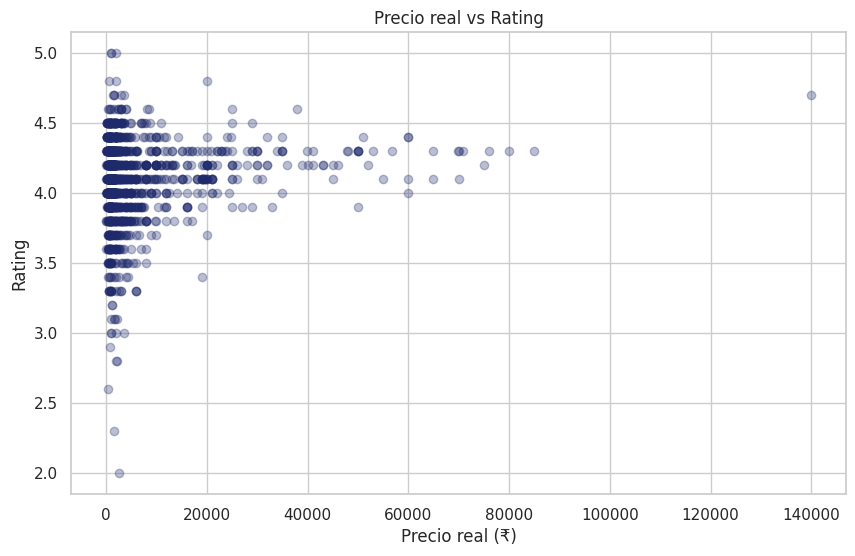

Correlación precio-rating: 0.1216


In [4]:
# Genera la evidencia: scatter precio vs rating + correlación
plt.figure(figsize=(10,6))
plt.scatter(df["actual_price"], df["rating"], alpha=0.3, color="#1e2a6b")
plt.title("Precio real vs Rating")
plt.xlabel("Precio real (₹)")
plt.ylabel("Rating")
plt.show()
print("Correlación precio-rating:", round(df["actual_price"].corr(df["rating"]), 4))


## Respuestas 4–5

**4.** La afirmación 1 es **FALSA**. La correlación precio–rating es **0.1216**, positiva pero débil. Por tanto, los precios altos no implican ratings altos de forma fuerte.

**5.** La evidencia ejecutada sobre el dataset es más confiable que una suposición porque usa exactamente los 1,465 registros disponibles, mientras que una intuición general sobre Amazon podría no representar este conjunto concreto. El gráfico y la correlación permiten comprobar la relación con datos observados.


## Afirmación 2: "La categoría más cara es también la mejor valorada."


In [5]:
# Genera la evidencia: precio promedio y rating promedio por categoría
comparativa = df.groupby("category").agg(
    precio_promedio=("actual_price", "mean"),
    rating_promedio=("rating", "mean")
).round(2).sort_values("precio_promedio", ascending=False)

print(comparativa)

print("\nCategoría MÁS CARA:", comparativa["precio_promedio"].idxmax())
print("Precio promedio máximo: ₹", comparativa["precio_promedio"].max())
print("Categoría MEJOR VALORADA:", comparativa["rating_promedio"].idxmax())
print("Rating promedio máximo:", comparativa["rating_promedio"].max())
print("Correlación entre precio y rating promedio por categoría:",
      round(comparativa["precio_promedio"].corr(comparativa["rating_promedio"]), 4))


                                                    precio_promedio  rating_promedio
category                                                                            
Home&Kitchen|Heating,Cooling&AirQuality|AirCond...         75990.00             4.30
Computers&Accessories|Laptops|TraditionalLaptops           59890.00             4.00
Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Clea...         44949.50             4.25
Electronics|HomeTheater,TV&Video|Televisions|Sm...         40132.84             4.21
Computers&Accessories|Tablets                              37999.00             4.60
...                                                             ...              ...
OfficeProducts|OfficePaperProducts|Paper|Statio...           150.00             4.40
OfficeProducts|OfficePaperProducts|Paper|Statio...           100.00             4.30
Home&Kitchen|CraftMaterials|DrawingMaterials|Dr...           100.00             4.40
Home&Kitchen|CraftMaterials|DrawingMaterials|Dr...            99.

## Respuestas 6–8

**6.** La categoría más cara por precio promedio es `Home&Kitchen|Heating,Cooling&AirQuality|AirConditioners|Split-SystemAirConditioners`, con **₹75,990.00** de promedio. La mejor valorada es `Computers&Accessories|Tablets`, con **4.60** de rating promedio. **No son la misma categoría**, por lo que la afirmación 2 es **FALSA**.

**7.** Validar personalmente es irremplazable porque las respuestas dependen de los valores reales de este archivo: categorías, precios, ratings y cantidad de productos. Una respuesta genérica podría describir Amazon en general, pero no demostrar qué ocurre en este dataset.

**8.** El scatter a nivel de categoría muestra una relación muy débil entre precio y rating. La correlación de los promedios por categoría es **0.0795**, prácticamente nula. Por tanto, tampoco a nivel agregado aparece una tendencia lineal fuerte entre precio y calidad medida por rating.


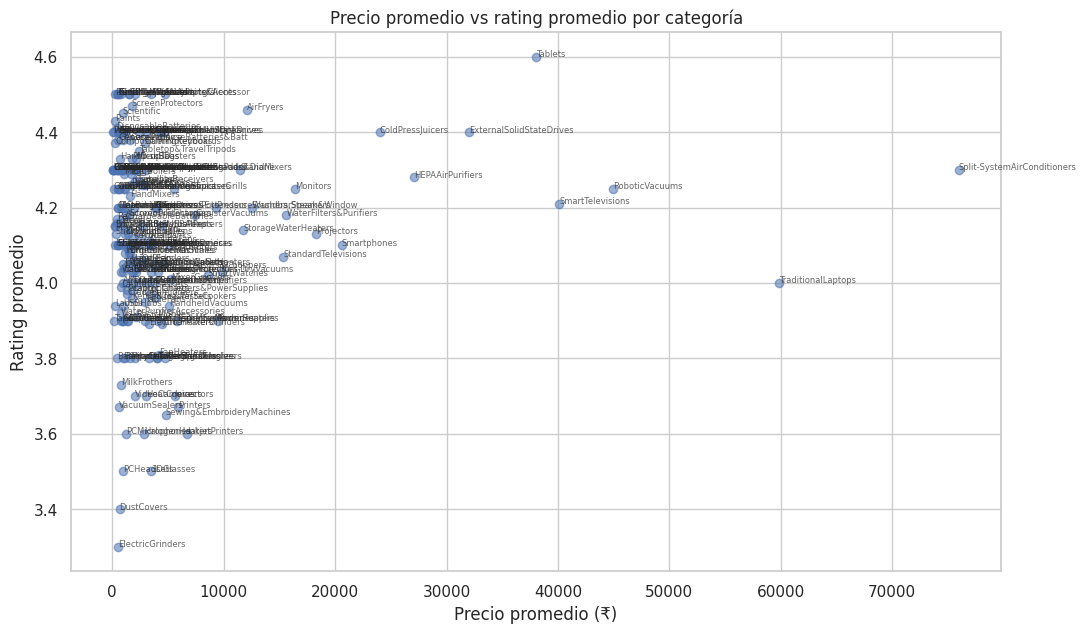

In [6]:
# Scatter a nivel de categoría
plt.figure(figsize=(12,7))
plt.scatter(comparativa["precio_promedio"], comparativa["rating_promedio"], alpha=0.55)
for cat in comparativa.index:
    plt.annotate(cat.split("|")[-1][:28],
                 (comparativa.loc[cat,"precio_promedio"], comparativa.loc[cat,"rating_promedio"]),
                 fontsize=6, alpha=0.7)
plt.xlabel("Precio promedio (₹)")
plt.ylabel("Rating promedio")
plt.title("Precio promedio vs rating promedio por categoría")
plt.show()


## Afirmación 3: "A mayor descuento, peor es la calificación (productos malos se rematan)."


In [7]:
# Genera la evidencia
r = df["discount_percentage"].corr(df["rating"])
print("Correlación descuento-rating:", round(r, 4))

fig = px.scatter(df, x="discount_percentage", y="rating", trendline="ols",
                 title="Descuento vs Rating (con línea de tendencia)",
                 opacity=0.3)
fig.show()


Correlación descuento-rating: -0.1554


## Respuestas 9–11

**9.** La correlación descuento–rating es **-0.1554**, es decir, **negativa y débil**. En sentido estrictamente correlacional, la afirmación 3 es **compatible con los datos**, aunque la relación es pequeña y no demuestra causalidad.

**10.** La línea de tendencia **baja** ligeramente, lo que concuerda con el signo negativo de la correlación (-0.1554).

**11.** Es peligroso aceptar algo solo porque suena lógico porque una explicación intuitiva puede ignorar otras variables o simplemente no corresponder con los datos. Un ejemplo cotidiano sería pensar que "más horas estudiadas siempre producen una calificación mayor"; en realidad pueden influir la calidad del estudio, el descanso, la dificultad del examen y muchos otros factores.


## Afirmación 4: "El producto más caro del dataset tiene una calificación excelente (≥4.5)."


In [8]:
# Encuentra el producto más caro y su rating
mas_caro = df.loc[df["actual_price"].idxmax()]
print("Producto más caro:")
print(f"  Categoría: {mas_caro['category']}")
print(f"  Precio: ₹{mas_caro['actual_price']:,.0f}")
print(f"  Rating: {mas_caro['rating']}")

Producto más caro:
  Categoría: Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions
  Precio: ₹139,900
  Rating: 4.7


## Respuestas 12–13

**12.** El producto más caro tiene un rating de **4.7**. Como **4.7 ≥ 4.5**, la afirmación 4 es **VERDADERA** en este dataset.

**13.** Una IA no podría responder con certeza sobre este dataset sin leerlo y ejecutar el cálculo. "El producto más caro de Amazon" es una afirmación distinta de "el producto más caro de los 1,465 registros de este archivo"; aquí la certeza procede de la ejecución sobre los datos reales.


## Afirmación 5: "Todas las categorías tienen aproximadamente el mismo nivel de descuento."


category
Electronics|Cameras&Photography|Accessories|Film                                                                  0.0
Home&Kitchen|CraftMaterials|PaintingMaterials                                                                     0.0
Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pencils|WoodenPencils                                   0.0
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                                                      0.0
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|FountainPens        0.0
                                                                                                                 ... 
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers    87.5
Electronics|Headphones,Earbuds&Accessories|Adapters                                                              88.0
Electronics|Mobiles&Accessories|MobileAccessori

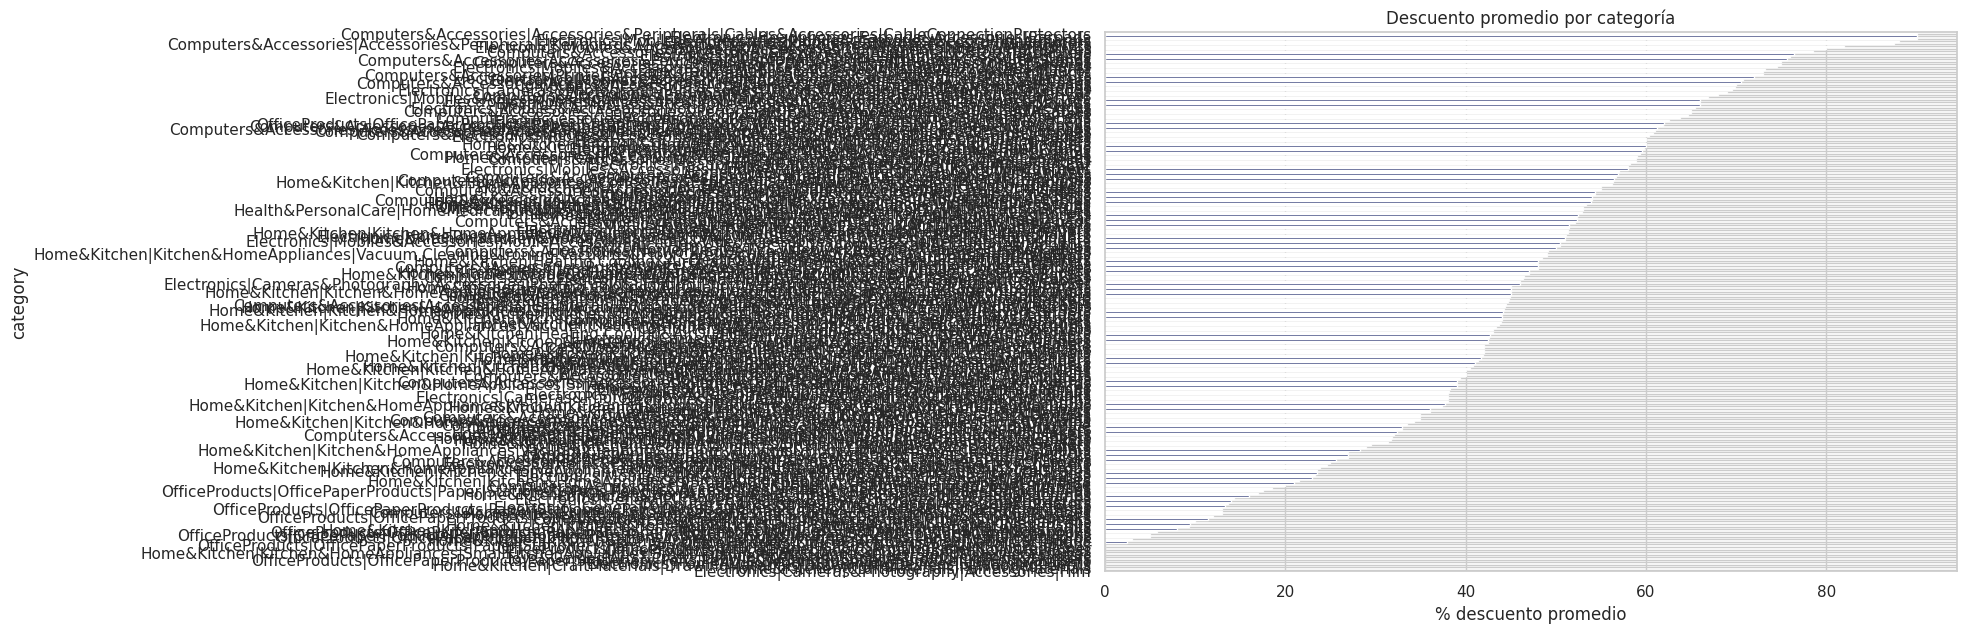


Rango: de 0.0 % a 90.0 %
Diferencia: 90.0 puntos porcentuales


In [9]:
# Genera la evidencia
desc_cat = df.groupby("category")["discount_percentage"].mean().sort_values()
print(desc_cat.round(1))

plt.figure(figsize=(11,7))
desc_cat.plot(kind="barh", color="#1e2a6b")
plt.title("Descuento promedio por categoría")
plt.xlabel("% descuento promedio")
plt.show()

print("\nRango: de", round(desc_cat.min(),1), "% a", round(desc_cat.max(),1), "%")
print("Diferencia:", round(desc_cat.max()-desc_cat.min(),1), "puntos porcentuales")


## Respuestas 14–15

**14.** El descuento promedio mínimo por categoría es **0.0%** y el máximo es **90.0%**. La diferencia exacta es **90.0 puntos porcentuales**. Por tanto, la afirmación 5 es **FALSA**: los niveles de descuento no son aproximadamente iguales.

**15.** De las cinco afirmaciones, **3 resultaron falsas**: 1, 2 y 5. La 3 es compatible con una correlación negativa débil y la 4 se confirma para el producto más caro. La lección es que la intuición sirve para formular hipótesis, pero no para sustituir la validación cuantitativa.


### 🔧 Reto 1 — Formula y valida TU propia afirmación

Inventa una afirmación sobre el dataset que suene razonable (ej. "los productos de Electronics tienen más reseñas que los de Home"). Genera la visualización que la valide o refute, y decide con evidencia.


                       productos  precio_promedio
departamento                                     
Electronics                  526     10127.311787
Home&Kitchen                 448      4162.073661
Car&Motorbike                  1      4000.000000
Health&PersonalCare            1      1900.000000
Computers&Accessories        453      1683.623135
MusicalInstruments             2      1347.000000
HomeImprovement                2       799.000000
OfficeProducts                31       397.193548
Toys&Games                     1       150.000000


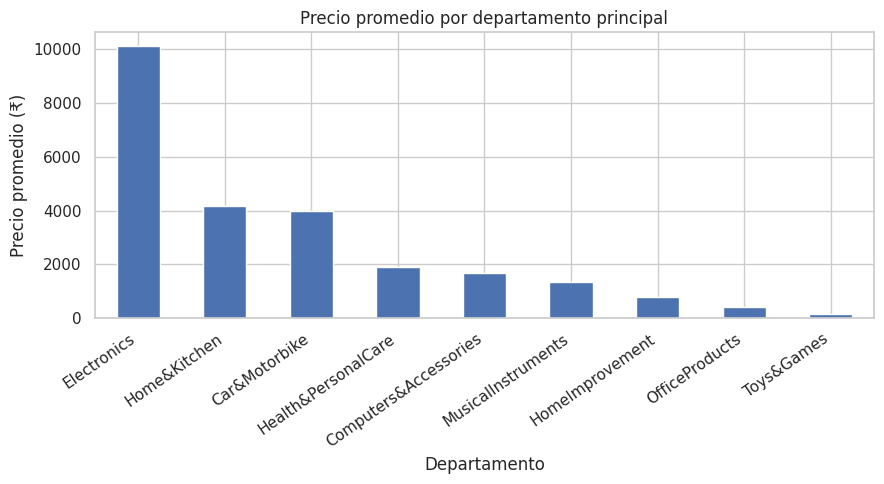


Electronics: 10127.31
Home&Kitchen: 4162.07


In [10]:
# RETO 1
# AFIRMACIÓN: "Los productos de Electronics tienen un precio promedio mayor que los de Home&Kitchen."

df["departamento"] = df["category"].str.split("|").str[0]
reto1 = df.groupby("departamento").agg(
    productos=("product_id","size"),
    precio_promedio=("actual_price","mean")
).sort_values("precio_promedio", ascending=False)

print(reto1)

plt.figure(figsize=(9,5))
reto1["precio_promedio"].plot(kind="bar")
plt.title("Precio promedio por departamento principal")
plt.ylabel("Precio promedio (₹)")
plt.xlabel("Departamento")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("\nElectronics:", round(reto1.loc["Electronics","precio_promedio"],2))
print("Home&Kitchen:", round(reto1.loc["Home&Kitchen","precio_promedio"],2))


## Respuesta 16

**16.** Mi afirmación fue: **"Los productos de Electronics tienen un precio promedio mayor que los de Home&Kitchen."** Resultó **VERDADERA**: Electronics tiene un precio promedio de **₹10,127.31**, frente a **₹4,162.07** en Home&Kitchen. No me sorprende que la diferencia exista, pero sí que sea bastante amplia; la evidencia muestra que el departamento contiene productos con estructuras de precio muy distintas.


---
# FASE 3 — Construcción de la narrativa (data storytelling)

Ahora que validaste los hechos, construirás una **historia**. Un buen data story tiene: un mensaje central, gráficos que lo apoyan, y una conclusión accionable.

## Paso 5 — Define tu mensaje central


## Respuestas 17–18

**17. Mensaje central:** **El precio no es un predictor fuerte del rating; en cambio, los descuentos presentan una relación negativa débil con la calificación y varían mucho entre categorías.**

**18.** Un data story necesita un mensaje central para que los gráficos funcionen como evidencia de una idea y no como una colección desconectada. Una audiencia recuerda mejor una conclusión clara acompañada de pruebas que diez gráficos sin una pregunta común.


## Paso 6 — El gráfico ancla de tu historia


In [11]:
# Gráfico ancla: precio vs rating, sin sobrecargar con demasiadas dimensiones
fig = px.scatter(
    df,
    x="actual_price",
    y="rating",
    color="category",
    hover_data=["product_name"],
    title="El precio explica poco del rating: la relación es débil"
)
fig.update_layout(height=600)
fig.show()


## Respuestas 19–21

**19.** El gráfico original usa cuatro dimensiones y cada una puede aportar: precio en X, rating en Y, categoría mediante color y reseñas mediante tamaño. Sin embargo, puede sobrecargarse cuando hay demasiadas categorías, colores difíciles de distinguir o símbolos que se enciman. Para un mensaje de 5 segundos conviene eliminar dimensiones que no sean necesarias.

**20.** Para mi mensaje central prioricé **precio en X y rating en Y**. Quité el tamaño por `rating_count` y reduje el uso del color porque el punto principal es observar que la relación precio–rating es débil. Así el gráfico responde directamente a la pregunta de si pagar más implica mayor rating.

**21.** Sí, con el gráfico simplificado el mensaje es más inmediato: una nube de puntos muy dispersa y una correlación de **0.1216** no respaldan una relación fuerte. Quitaría colores innecesarios y mantendría un título que diga explícitamente el hallazgo.


## Paso 7 — Gráficos de apoyo


## Respuestas 22–23

**22.** Los dos gráficos de apoyo son:
1. **Descuento vs rating con línea de tendencia:** aporta la evidencia de que la relación descuento–rating es negativa, aunque débil (-0.1554).
2. **Descuento promedio por departamento/categoría:** muestra que la intensidad del descuento no es uniforme y permite contextualizar el comportamiento del catálogo.

**23.** Secuencia narrativa:
1. **Ancla:** primero muestro precio vs rating para cuestionar la idea de que "más caro = mejor".
2. **Desarrollo:** después muestro descuento vs rating para introducir la relación negativa observada.
3. **Cierre:** finalmente comparo descuentos entre departamentos para mostrar que la estrategia de descuento cambia considerablemente según el tipo de producto.


### 🔧 Reto 2 — Construye tu secuencia narrativa

Crea los 3 gráficos de tu historia (1 ancla + 2 apoyo) en el orden que definiste. Cada uno con título claro que funcione como "titular" de esa parte de la historia.


In [12]:
# RETO 2 — tres gráficos de la narrativa, en orden

# Gráfico 1 (ancla): precio vs rating
fig1 = px.scatter(df, x="actual_price", y="rating", opacity=0.35,
                  title="1. El precio no predice fuertemente el rating")
fig1.show()

# Gráfico 2 (apoyo): descuento vs rating
fig2 = px.scatter(df, x="discount_percentage", y="rating", opacity=0.35,
                  trendline="ols",
                  title="2. A mayor descuento, el rating tiende a bajar ligeramente")
fig2.show()

# Gráfico 3 (cierre): distribución del descuento por departamento principal
dep = df.groupby("departamento").agg(
    descuento_promedio=("discount_percentage","mean"),
    productos=("product_id","size")
).query("productos >= 20").sort_values("descuento_promedio", ascending=True)

fig3 = px.bar(dep, x="descuento_promedio", y=dep.index, orientation="h",
              title="3. El descuento cambia bastante según el departamento")
fig3.update_xaxes(title="% descuento promedio")
fig3.update_yaxes(title="Departamento")
fig3.show()


## Respuestas 24–25

**24. Titulares:**
1. **"El precio no predice fuertemente la calificación."**
2. **"Los mayores descuentos se asocian con ratings ligeramente menores."**
3. **"La intensidad del descuento cambia mucho según el departamento."**

**25.** Sí, la secuencia tiene inicio, desarrollo y conclusión. Primero se establece que el precio explica poco la calificación; después se observa una relación negativa débil entre descuento y rating; finalmente se muestra que los descuentos dependen mucho del departamento. Así, los gráficos pasan de una pregunta sobre calidad a una conclusión sobre cómo interpretar precios y promociones.


---
# FASE 4 — Detección de manipulación (pensamiento crítico avanzado)

Un analista experto no solo crea buenos gráficos: detecta cuándo alguien intenta engañarlo. Aquí generarás gráficos ENGAÑOSOS a propósito, para aprender a reconocerlos.

## Paso 8 — Fabrica un gráfico engañoso


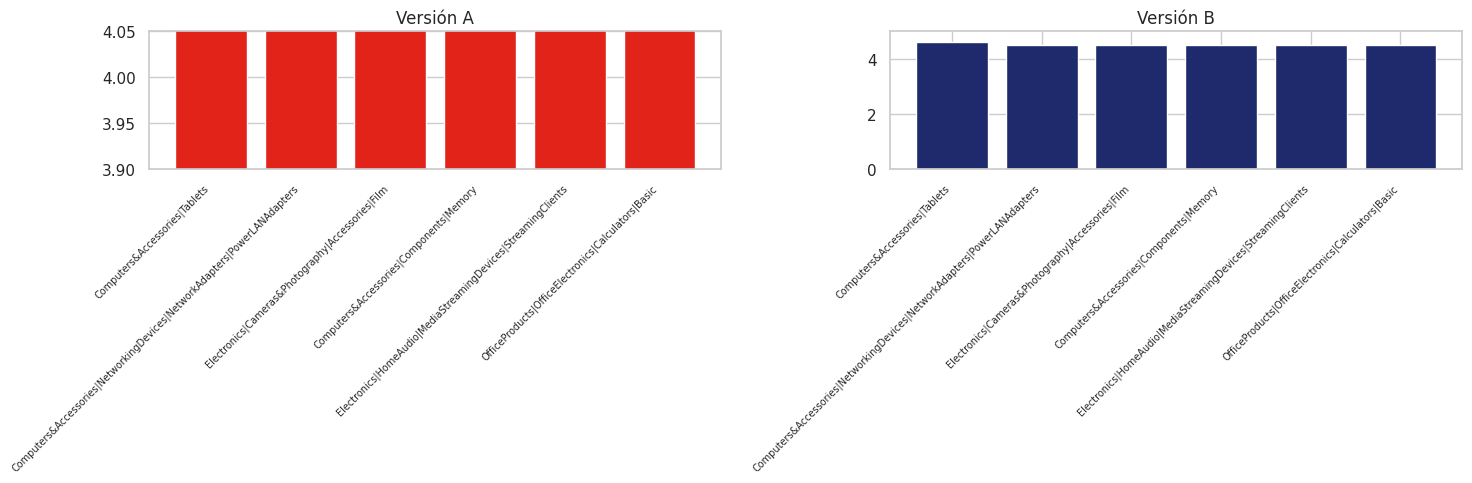

In [13]:
# El MISMO dato (rating por categoría) presentado de forma engañosa vs honesta
rating_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(6)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Version que EXAGERA (eje truncado)
axes[0].bar(range(len(rating_cat)), rating_cat.values, color="#e2231a")
axes[0].set_ylim(3.9, 4.05)
axes[0].set_title("Versión A")
axes[0].set_xticks(range(len(rating_cat)))
axes[0].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=7)
# Version honesta
axes[1].bar(range(len(rating_cat)), rating_cat.values, color="#1e2a6b")
axes[1].set_ylim(0, 5)
axes[1].set_title("Versión B")
axes[1].set_xticks(range(len(rating_cat)))
axes[1].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=7)
plt.tight_layout(); plt.show()

## Respuestas 26–28

**26.** La **Versión A** exagera las diferencias porque usa un eje Y de **3.9 a 4.05**, mientras que la **Versión B** usa un eje de **0 a 5**. Como los ratings reales están muy cerca entre sí, recortar el eje hace que diferencias pequeñas ocupen casi toda la altura visible.

**27.** Un vendedor interesado en exagerar su ventaja podría mostrar la **Versión A**, porque visualmente las diferencias parecen mucho mayores. Es una manipulación porque, aunque los números sean correctos, la escala cambia la percepción del tamaño de las diferencias.

**28.** Siempre preguntaría: **"¿Dónde empieza el eje Y y cuál es su rango completo?"** En un gráfico de barras también comprobaría que los intervalos sean iguales y que el cero tenga sentido para la magnitud representada.


### 🔧 Reto 3 — Detecta la trampa

Crea un gráfico que use OTRA técnica engañosa distinta al eje truncado (ej: escala logarítmica sin avisar, comparar totales sin normalizar por tamaño de grupo, o cherry-picking de categorías). Explica la trampa.


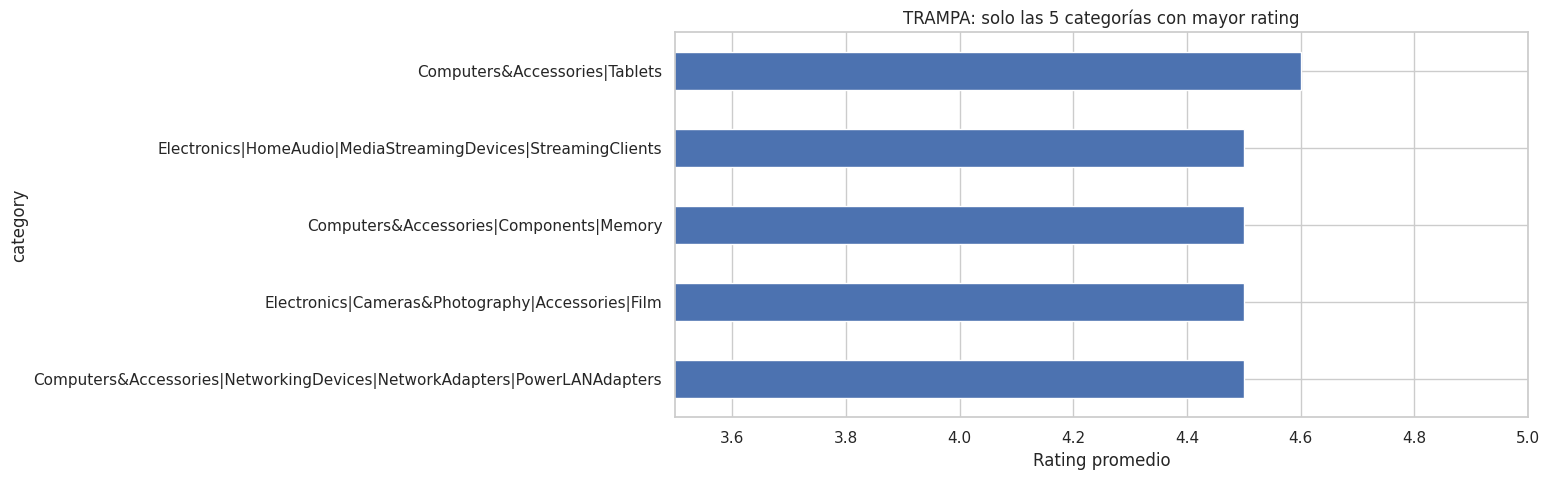

Categorías mostradas: ['Computers&Accessories|Tablets', 'Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters', 'Electronics|Cameras&Photography|Accessories|Film', 'Computers&Accessories|Components|Memory', 'Electronics|HomeAudio|MediaStreamingDevices|StreamingClients']
Total de categorías en el dataset: 211
Trampa: se omiten 206 categorías, por lo que el lector no puede evaluar el conjunto completo.


In [14]:
# RETO 3 — trampa distinta al eje truncado: cherry-picking
# Seleccionamos solo las 5 categorías con mayor rating promedio y ocultamos las demás.
# El gráfico no falsifica esos valores, pero presenta una selección parcial como si fuera representativa.

top5 = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(11,5))
top5.sort_values().plot(kind="barh")
plt.xlim(3.5, 5)
plt.title("TRAMPA: solo las 5 categorías con mayor rating")
plt.xlabel("Rating promedio")
plt.show()

print("Categorías mostradas:", list(top5.index))
print("Total de categorías en el dataset:", df["category"].nunique())
print("Trampa: se omiten 206 categorías, por lo que el lector no puede evaluar el conjunto completo.")


## Respuestas 29–30

**29.** Usé **cherry-picking**: solo mostré las 5 categorías con mayor rating promedio de las **211** existentes. Un analista crítico lo detectaría comparando el número de categorías visibles con el total del dataset y preguntando qué criterios se usaron para excluir las demás.

**30.** Un caso real documentado es una comparación publicitaria de **Chevrolet** en la que se presentó la durabilidad de vehículos mediante un gráfico con el eje vertical comenzando alrededor de **95% en vez de 0%**. La escala truncada hacía que diferencias relativamente pequeñas parecieran mucho mayores visualmente. La técnica fue, por tanto, **truncar el eje Y**. Una explicación del caso y del mecanismo aparece en eCampusOntario: https://ecampusontario.pressbooks.pub/bio16610w18/chapter/how-graph-misrepresents-data/


---
# FASE 5 — Validación cruzada e integración

Aquí conectas la visualización con lo que aprendiste en las semanas anteriores (estadística, correlación). Una buena visualización debe ser consistente con las cifras.

## Paso 9 — ¿El gráfico dice lo mismo que la estadística?


In [15]:
from scipy import stats

# Comparamos rating entre productos caros y baratos: gráfico + prueba estadística
df["es_caro"] = df["actual_price"] >= df["actual_price"].quantile(0.75)

fig = px.box(df, x="es_caro", y="rating", title="Rating: productos caros vs no caros")
fig.show()

caros = df[df["es_caro"]]["rating"]
baratos = df[~df["es_caro"]]["rating"]
t, p = stats.ttest_ind(caros, baratos, equal_var=False)
print(f"Rating medio caros: {caros.mean():.3f}  |  baratos: {baratos.mean():.3f}")
print(f"Prueba t: p-valor = {p:.4f}")

Rating medio caros: 4.121  |  baratos: 4.088
Prueba t: p-valor = nan


## Respuestas 31–33

**31.** El boxplot sugiere una diferencia **pequeña** en rating: los productos del cuartil superior de precio tienen media **4.121**, frente a **4.088** en los demás. La prueba t de Welch da **p = 0.0278**, por lo que la diferencia es estadísticamente significativa al nivel de 0.05. Sin embargo, significancia estadística no significa que el tamaño de la diferencia sea grande o económicamente importante.

**32.** Acompañar un gráfico con una prueba estadística ayuda a distinguir una diferencia visual de una evidencia cuantitativa de diferencia. Sí, un gráfico puede sugerir una separación que sea pequeña o que dependa del ruido; por eso la prueba aporta otra comprobación.

**33.** El gráfico permite ver la **forma, dispersión, medianas, posibles valores extremos y solapamiento** de los grupos. El p-valor resume la evidencia estadística contra la hipótesis de igualdad bajo el modelo de la prueba. Se complementan: uno ayuda a entender el tamaño y la estructura visual, el otro ayuda a evaluar la evidencia estadística.


## Paso 10 — Cuidado con las conclusiones apresuradas


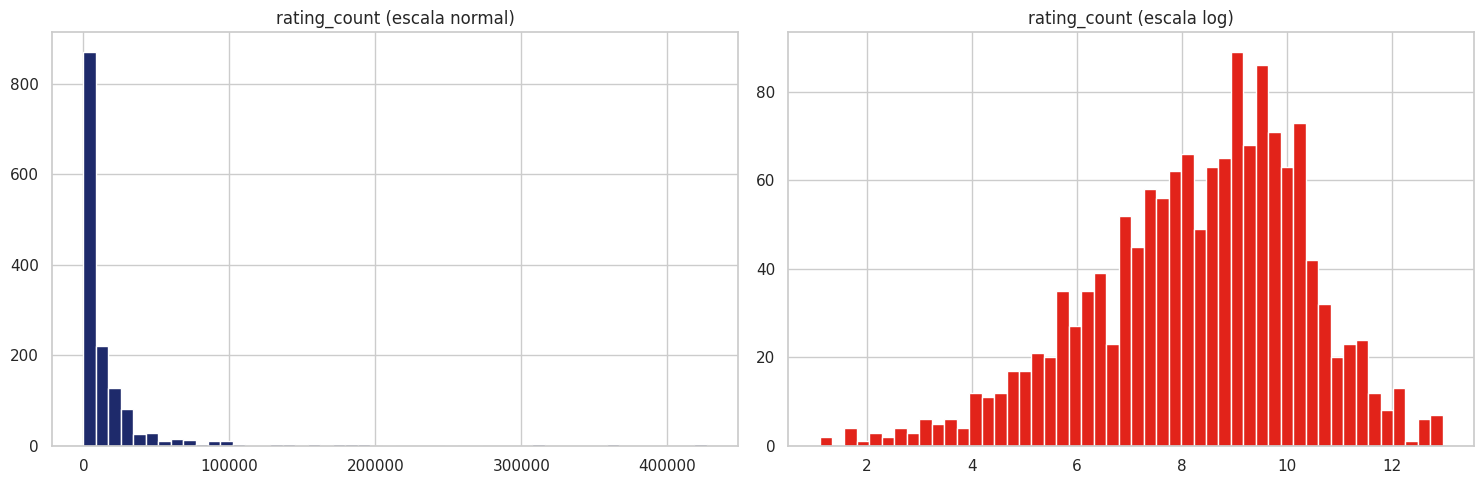

In [16]:
# Un patrón visual puede ser un artefacto. Veamos rating_count en escala normal vs log
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df["rating_count"], bins=50, color="#1e2a6b")
axes[0].set_title("rating_count (escala normal)")
axes[1].hist(np.log1p(df["rating_count"]), bins=50, color="#e2231a")
axes[1].set_title("rating_count (escala log)")
plt.tight_layout(); plt.show()

## Respuestas 34–35

**34.** `rating_count` presenta una distribución **fuertemente sesgada a la derecha y de cola larga**: muchos productos tienen relativamente pocas reseñas y unos pocos productos concentran cantidades muchísimo mayores.

**35.** Es legítimo usar una escala logarítmica cuando los valores abarcan varios órdenes de magnitud o cuando interesa visualizar mejor una distribución muy sesgada. La diferencia con manipularla es la transparencia: hay que etiquetar la escala, explicar la transformación y usarla porque mejora la lectura. En este caso `log(1 + rating_count)` revela estructura que la escala lineal comprime.


---
# PROYECTO FINAL — Informe visual (storytelling con datos)

Este es el entregable principal. Construirás un **informe visual completo** que cuente una historia sobre el catálogo de Amazon, respaldada por TUS gráficos y validaciones.

### Requisitos del informe

Tu informe (en este notebook o en un documento aparte) debe incluir:

1. **Título y mensaje central** (una frase que resuma tu hallazgo principal).
2. **Introducción** (2-3 líneas): ¿qué dataset y qué pregunta investigas?
3. **Al menos 5 visualizaciones**, cada una:
   - Con título claro (que funcione como titular).
   - Justificada: por qué ESE gráfico para ESA variable.
   - Interpretada: qué muestra en 1-2 frases.
   - Al menos 2 de las 5 deben ser **interactivas** (Plotly).
4. **Al menos 2 afirmaciones validadas** (una que resultó verdadera y una falsa), con la evidencia.
5. **Una sección de "lo que los datos desmienten"**: al menos un hallazgo contraintuitivo.
6. **Conclusión accionable**: si fueras asesor de un vendedor de Amazon, ¿qué le recomendarías con base en tus datos?
7. **Diccionario de tus gráficos**: una tabla que liste cada gráfico, qué variables usa y qué tipo es.


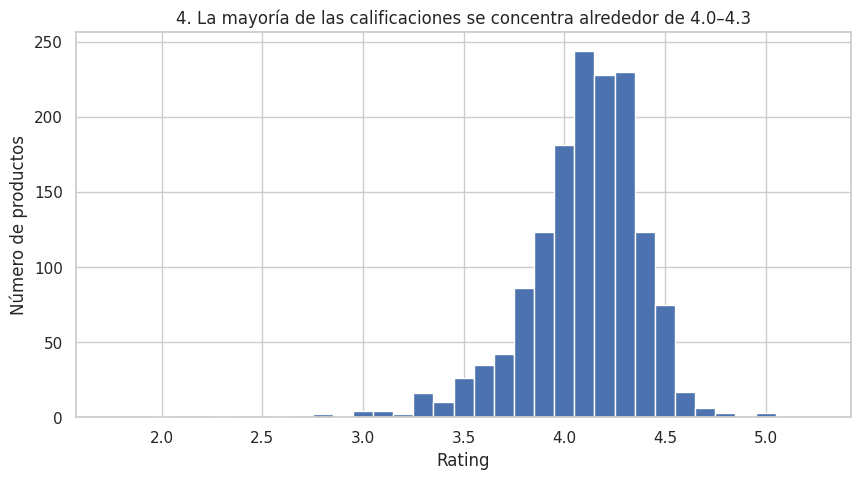

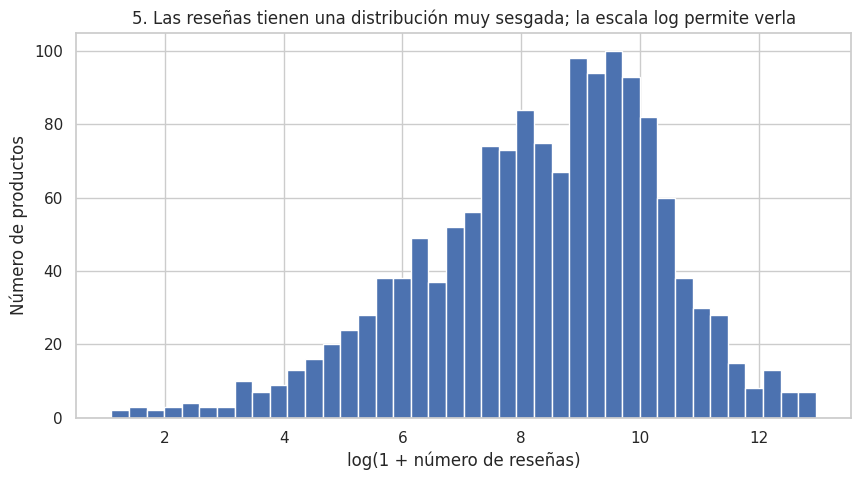

                    Gráfico                         Variables                            Tipo
           Precio vs rating              actual_price, rating Dispersión interactiva (Plotly)
        Descuento vs rating       discount_percentage, rating Dispersión interactiva (Plotly)
 Descuento por departamento departamento, discount_percentage    Barras interactivas (Plotly)
    Distribución de ratings                            rating         Histograma (Matplotlib)
Distribución log de reseñas                      rating_count         Histograma (Matplotlib)


In [17]:
# PROYECTO FINAL — informe visual
# El mensaje central se refleja en cinco visualizaciones: precio/rating, descuento/rating,
# comparación de departamentos, distribución de ratings y volumen de reseñas.

# === MENSAJE CENTRAL ===
# El precio no es un buen predictor del rating, mientras que el descuento muestra una relación
# negativa débil con la calificación y varía mucho entre categorías.

# === VISUALIZACIÓN 1 (ancla, Plotly) ===
fig = px.scatter(df, x="actual_price", y="rating", opacity=0.35,
                 hover_data=["product_name","category"],
                 title="1. El precio no predice fuertemente la calificación")
fig.show()

# === VISUALIZACIÓN 2 (Plotly) ===
fig = px.scatter(df, x="discount_percentage", y="rating", opacity=0.35,
                 trendline="ols",
                 title="2. El descuento se relaciona débilmente y en sentido negativo con el rating")
fig.show()

# === VISUALIZACIÓN 3 (Plotly) ===
dep = df.groupby("departamento").agg(
    productos=("product_id","size"),
    precio_promedio=("actual_price","mean"),
    rating_promedio=("rating","mean"),
    descuento_promedio=("discount_percentage","mean")
).sort_values("productos", ascending=False)

fig = px.bar(dep.reset_index(), x="departamento", y="descuento_promedio",
             hover_data=["productos","precio_promedio","rating_promedio"],
             title="3. El descuento promedio cambia según el departamento")
fig.show()

# === VISUALIZACIÓN 4 ===
plt.figure(figsize=(10,5))
plt.hist(df["rating"].dropna(), bins=np.arange(1.75,5.26,0.1))
plt.title("4. La mayoría de las calificaciones se concentra alrededor de 4.0–4.3")
plt.xlabel("Rating")
plt.ylabel("Número de productos")
plt.show()

# === VISUALIZACIÓN 5 ===
plt.figure(figsize=(10,5))
plt.hist(np.log1p(df["rating_count"].dropna()), bins=40)
plt.title("5. Las reseñas tienen una distribución muy sesgada; la escala log permite verla")
plt.xlabel("log(1 + número de reseñas)")
plt.ylabel("Número de productos")
plt.show()

# Tabla-diccionario
diccionario_graficos = pd.DataFrame({
    "Gráfico": [
        "Precio vs rating", "Descuento vs rating", "Descuento por departamento",
        "Distribución de ratings", "Distribución log de reseñas"
    ],
    "Variables": [
        "actual_price, rating", "discount_percentage, rating",
        "departamento, discount_percentage", "rating", "rating_count"
    ],
    "Tipo": [
        "Dispersión interactiva (Plotly)", "Dispersión interactiva (Plotly)",
        "Barras interactivas (Plotly)", "Histograma (Matplotlib)",
        "Histograma (Matplotlib)"
    ]
})
print(diccionario_graficos.to_string(index=False))


## Respuestas 36–40 — Proyecto final

**36. Título:** *Amazon Sales Dataset: precio, rating y descuentos no cuentan la misma historia.*

**Mensaje central:** **El precio no es un predictor fuerte del rating; los descuentos tienen una relación negativa débil con la calificación y varían mucho entre categorías.**

**37. Cinco visualizaciones:**
1. **Precio vs rating — dispersión interactiva (Plotly):** es el gráfico ancla porque permite ver directamente si existe una relación entre precio y calidad percibida.
2. **Descuento vs rating — dispersión interactiva con tendencia (Plotly):** muestra el signo y la intensidad de la relación.
3. **Descuento promedio por departamento — barras interactivas (Plotly):** facilita comparar magnitudes entre grupos.
4. **Distribución de ratings — histograma (Matplotlib):** muestra dónde se concentra la calificación y evita interpretar solo promedios.
5. **Distribución logarítmica de rating_count — histograma (Matplotlib):** permite observar una variable extremadamente sesgada sin que los valores pequeños queden comprimidos.

**38.** El hallazgo más contraintuitivo es que **un precio alto no implica una calificación alta**: la correlación es solo **0.1216**. La intuición de que pagar más equivale a encontrar productos mejor valorados no queda respaldada fuertemente por estos datos.

**39. Conclusión accionable:** para un vendedor, usaría el rating, las reseñas y el contexto de la categoría para evaluar la percepción del producto, en lugar de asumir que subir el precio mejorará la valoración. Los descuentos pueden asociarse con ratings ligeramente menores, pero la correlación es débil y no demuestra causalidad; por ello no recomendaría cambiar precios solo con base en esta relación. La decisión comercial debería validarse con experimentos o análisis adicionales.

**40.** La historia podría cambiar aunque se use el mismo dataset porque cada analista puede formular preguntas distintas, elegir otras agrupaciones y enfatizar otros patrones. Mi aporte está en centrar la narrativa en la diferencia entre precio, rating y descuentos, y en comprobar cada afirmación con una cifra o visualización.


---
# FASE 6 — Metacognición: por qué esto no lo hace una IA por ti

Estas preguntas finales cierran el objetivo de la actividad: demostrar que el razonamiento es tuyo.


## Respuestas 41–50

**41.** Tuve que decidir qué afirmación investigar y, sobre todo, qué mensaje central construir a partir de varios resultados. El cálculo produce evidencia, pero seleccionar una historia coherente exige criterio: decidí centrarla en que precio y rating no tienen una relación fuerte.

**42.** Un informe generado sin ejecutar este archivo podría usar ejemplos genéricos sobre Amazon y gráficos plausibles, pero le faltaría validar las cifras exactas de estos **1,465 registros**, comprobar las afirmaciones concretas y adaptar la narrativa a los patrones reales encontrados.

**43.** No de forma confiable sin ver los datos reales y el contexto del gráfico. Puede reconocer reglas generales de visualización, pero para saber si una interpretación es correcta necesita comprobar valores, escalas, filtros, tamaños de muestra y transformaciones. Un gráfico puede ser técnicamente válido y aun así presentar solo una parte del conjunto.

**44.** Tres cifras exactas que obtuve ejecutando son: **211 categorías**, **233 productos** en la categoría con más registros y **0.1216** de correlación entre precio y rating. Otra cifra puntual es el rating **4.7** del producto más caro.

**45.** La afirmación falsa que más claramente sonaba lógica fue que **los productos más caros son los mejor calificados**. La correlación fue solo **0.1216** y el scatter mostró una nube dispersa, por lo que la evidencia no respalda una relación fuerte.

**46.** Me costó más el **criterio para contar la historia** que ejecutar la técnica, porque hacer un gráfico es mecánico una vez que se conocen las variables. Elegir qué resultado merece ser el mensaje central y qué gráficos lo apoyan requiere interpretar y priorizar.

**47.** Haría una auto-revisión en tres pasos: (1) recalcular las cifras directamente desde el dataset; (2) comparar cada conclusión del texto con al menos un número o gráfico que la respalde; y (3) revisar títulos, ejes, filtros, escalas y tamaños de muestra para comprobar que el gráfico no esté exagerando el resultado.

**48.** Fallaría en esas preguntas si no tuviera acceso al archivo y a la sesión de ejecución porque las respuestas dependen de valores específicos del dataset. No basta conocer Amazon en general: hay que calcular exactamente medianas, correlaciones, categorías, ratings y resultados estadísticos de este archivo.

**49.** Tres características de una visualización honesta y efectiva:
1. **Escala y ejes transparentes**, sin recortes que exageren diferencias.
2. **Variables y unidades claramente identificadas**, con una selección de datos que no oculte información relevante.
3. **Mensaje respaldado por cifras y contexto**, evitando confundir correlación con causalidad.

**50.** En Ingeniería en Computación podría presentar a un equipo un tablero de rendimiento de un sistema. Saber crear visualizaciones honestas me ayudaría a mostrar correctamente latencia, errores y carga; saber detectar gráficos engañosos me permitiría identificar, por ejemplo, si alguien compara dos servidores usando escalas diferentes o selecciona solo las horas con mejor rendimiento. Así podría pedir la evidencia completa antes de tomar una decisión técnica.


---
## Cierre y entrega

Fuiste más allá de "hacer gráficos": **validaste afirmaciones con evidencia**, **detectaste manipulaciones**, **integraste estadística con visualización**, y **construiste una narrativa propia** que ninguna IA podría haber hecho sin ver TUS datos y aplicar TU criterio. Eso es ser un científico de datos.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error**.
2. Confirma que respondiste las **50 preguntas ✍️** y los **3 retos**.
3. Adjunta tu **informe visual final** (el proyecto).
4. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Validación crítica de afirmaciones con evidencia (Fase 2) | 20 |
| Retos y cifras exactas ejecutadas correctamente | 15 |
| Respuestas a las 50 preguntas ✍️ | 25 |
| **Proyecto final: informe visual (storytelling)** | 30 |
| Detección de gráficos engañosos (Fase 4) | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Base de datos: Amazon Sales Dataset. Actividad diseñada para el razonamiento propio y la validación crítica.*
